# Week 1 Day 5 — Advanced Imbalance Handling for ICU Sepsis Prediction

The objective of Day 5 is to improve septic patient detection using SMOTE, threshold optimization, and recall-focused model evaluation.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

## Creating Output Folders

Folders are created to automatically save Day 5 figures and result files.

In [4]:
os.makedirs("../figures/day5", exist_ok=True)
os.makedirs("../results", exist_ok=True)

## Loading the Processed ICU Dataset

The processed ICU dataset generated during previous preprocessing stages is loaded for advanced model development.

In [7]:
df = pd.read_csv("../data/processed/day2_patient_level_features.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (100, 18)


,Patient_ID,HR_mean,HR_max,HR_min,O2Sat_mean,O2Sat_min,Temp_mean,Temp_max,SBP_mean,SBP_min,MAP_mean,MAP_min,Resp_mean,Resp_max,Age_first,Gender_first,ICULOS_max,SepsisLabel_max
0,p000001,101.907407,117.0,76.0,91.453704,85.0,36.735185,37.44,127.870370,78.0,88.321111,44.00,24.555556,32.0,83.14,0,54,0
1,p000002,62.173913,94.0,54.0,97.043478,94.0,36.206087,37.00,129.043478,114.0,67.239130,50.50,14.630435,27.0,75.91,0,23,0
2,p000003,79.968750,93.0,68.0,95.375000,91.0,37.465000,38.61,139.760417,121.0,81.149167,62.67,25.302083,40.0,45.82,0,48,0
3,p000004,102.172414,113.0,89.0,98.189655,95.5,36.463103,37.00,113.017241,90.0,67.063103,34.00,18.758621,26.0,65.71,0,29,0
4,p000005,76.604167,88.0,61.0,97.677083,96.0,37.072292,37.33,135.072917,114.0,90.364583,73.00,15.447917,21.0,28.09,1,49,0


## Analyzing Class Distribution

The sepsis label distribution is checked to confirm the presence of class imbalance.

In [10]:
target_col = "SepsisLabel_max"

print(df[target_col].value_counts())
print(df[target_col].value_counts(normalize=True) * 100)

SepsisLabel_max
0    86
1    14
Name: count, dtype: int64
SepsisLabel_max
0    86.0
1    14.0
Name: proportion, dtype: float64


## Separating Features and Target Variable

The dataset is divided into input features and the target sepsis label.

In [15]:
target_col = "SepsisLabel_max"

X = df.drop(columns=[target_col, "Patient_ID"])
y = df[target_col]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (100, 16)
Target shape: (100,)


## Stratified Train-Test Split

A stratified split is used to preserve the same sepsis distribution in both training and testing sets.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Applying SMOTE Oversampling

SMOTE is applied only to the training data to generate synthetic septic patient samples and reduce class imbalance.

In [17]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
SepsisLabel_max
0    69
1    11
Name: count, dtype: int64

After SMOTE:
SepsisLabel_max
0    69
1    69
Name: count, dtype: int64


## Training Random Forest with SMOTE

A Random Forest model is trained using the balanced SMOTE dataset to improve septic patient detection.

In [19]:
rf_smote = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=3
)

rf_smote.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_smote.predict(X_test)
y_proba_rf = rf_smote.predict_proba(X_test)[:, 1]

## Evaluating Random Forest Performance

The model is evaluated using accuracy, precision, recall, F1-score, and ROC-AUC.

In [20]:
rf_metrics = {
    "Model": "Random Forest + SMOTE",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf, zero_division=0),
    "Recall": recall_score(y_test, y_pred_rf, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_rf, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba_rf)
}

rf_metrics

{'Model': 'Random Forest + SMOTE',
 'Accuracy': 0.8,
 'Precision': 0.3333333333333333,
 'Recall': 0.3333333333333333,
 'F1-score': 0.3333333333333333,
 'ROC-AUC': 0.7254901960784313}

## Confusion Matrix Analysis

The confusion matrix shows how many septic and non-septic patients were correctly or incorrectly classified.

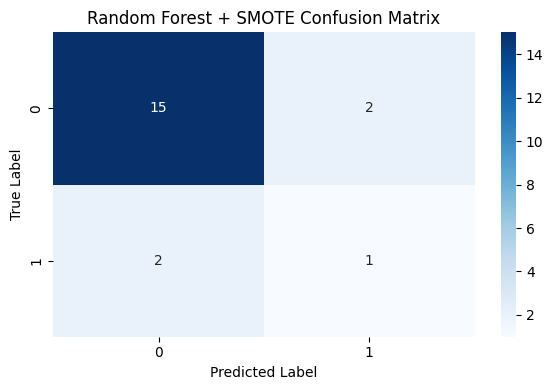

In [21]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest + SMOTE Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("../figures/day5/rf_smote_confusion_matrix.png", dpi=300)
plt.show()

## ROC Curve Analysis

The ROC curve evaluates how well the model separates septic from non-septic patients.

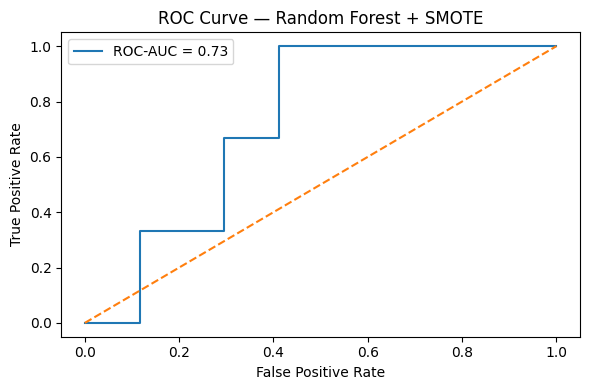

In [22]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf)
auc_score = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest + SMOTE")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/day5/rf_smote_roc_curve.png", dpi=300)
plt.show()

## Threshold Optimization

Different probability thresholds are tested to improve recall and reduce missed septic patients.

In [23]:
thresholds_to_test = np.arange(0.1, 0.9, 0.05)

threshold_results = []

for threshold in thresholds_to_test:
    y_pred_threshold = (y_proba_rf >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,Accuracy,Precision,Recall,F1-score
0,0.10,0.35,0.187500,1.000000,0.315789
1,0.15,0.35,0.187500,1.000000,0.315789
2,0.20,0.40,0.200000,1.000000,0.333333
3,0.25,0.50,0.230769,1.000000,0.375000
4,0.30,0.65,0.250000,0.666667,0.363636
5,0.35,0.70,0.285714,0.666667,0.400000
6,0.40,0.70,0.200000,0.333333,0.250000
7,0.45,0.80,0.333333,0.333333,0.333333
8,0.50,0.80,0.333333,0.333333,0.333333
9,0.55,0.75,0.000000,0.000000,0.000000


## Visualizing Threshold Performance

Recall, precision, and F1-score are compared across thresholds to select a clinically useful decision point.

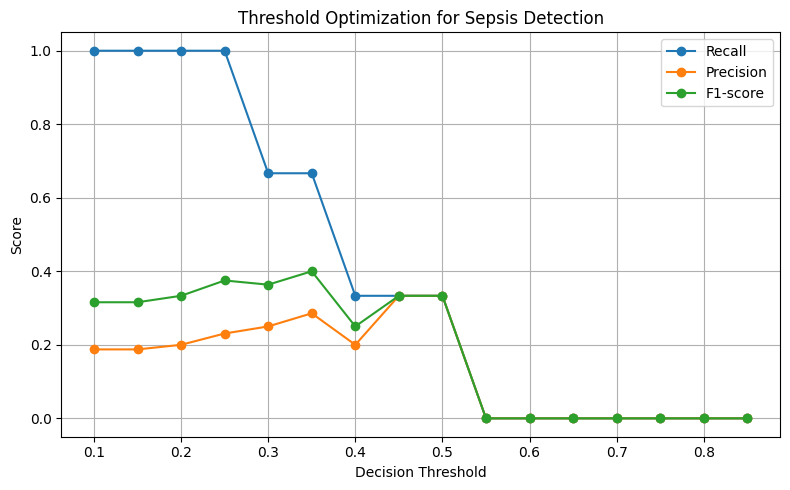

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["F1-score"], marker="o", label="F1-score")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization for Sepsis Detection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../figures/day5/threshold_optimization.png", dpi=300)
plt.show()

## Selecting the Best Recall-Focused Threshold

The threshold with the highest recall and strongest F1-score is selected for final optimized predictions.

In [25]:
best_threshold = threshold_df.sort_values(
    by=["Recall", "F1-score"],
    ascending=False
).iloc[0]["Threshold"]

print("Best threshold:", best_threshold)

Best threshold: 0.25000000000000006


## Evaluating Optimized Predictions

The optimized threshold is applied to generate final predictions focused on septic patient detection.

In [26]:
y_pred_optimized = (y_proba_rf >= best_threshold).astype(int)

optimized_metrics = {
    "Model": "Random Forest + SMOTE + Threshold Optimization",
    "Threshold": best_threshold,
    "Accuracy": accuracy_score(y_test, y_pred_optimized),
    "Precision": precision_score(y_test, y_pred_optimized, zero_division=0),
    "Recall": recall_score(y_test, y_pred_optimized, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_optimized, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba_rf)
}

optimized_metrics

{'Model': 'Random Forest + SMOTE + Threshold Optimization',
 'Threshold': np.float64(0.25000000000000006),
 'Accuracy': 0.5,
 'Precision': 0.23076923076923078,
 'Recall': 1.0,
 'F1-score': 0.375,
 'ROC-AUC': 0.7254901960784313}

## Optimized Confusion Matrix

The optimized confusion matrix shows whether threshold tuning improved septic patient detection.

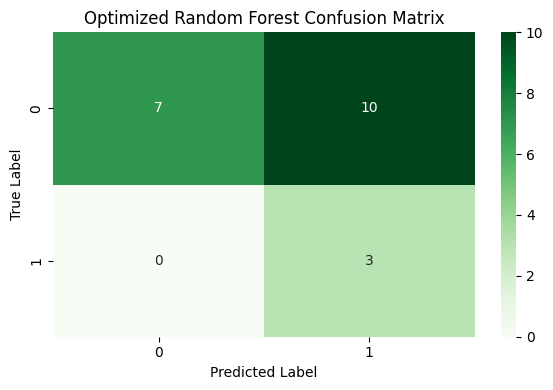

In [27]:
cm_opt = confusion_matrix(y_test, y_pred_optimized)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_opt, annot=True, fmt="d", cmap="Greens")
plt.title("Optimized Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("../figures/day5/optimized_confusion_matrix.png", dpi=300)
plt.show()

## Feature Importance Analysis

Feature importance is analyzed to identify the physiological variables most influential in sepsis prediction.

In [28]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_smote.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
2,HR_min,0.155400
15,ICULOS_max,0.114659
14,Gender_first,0.108034
7,SBP_mean,0.072419
3,O2Sat_mean,0.070983
5,Temp_mean,0.066493
13,Age_first,0.064392
9,MAP_mean,0.060898
1,HR_max,0.046824
0,HR_mean,0.045886


## Visualizing Feature Importance

The top predictive ICU variables are visualized to improve model interpretability.

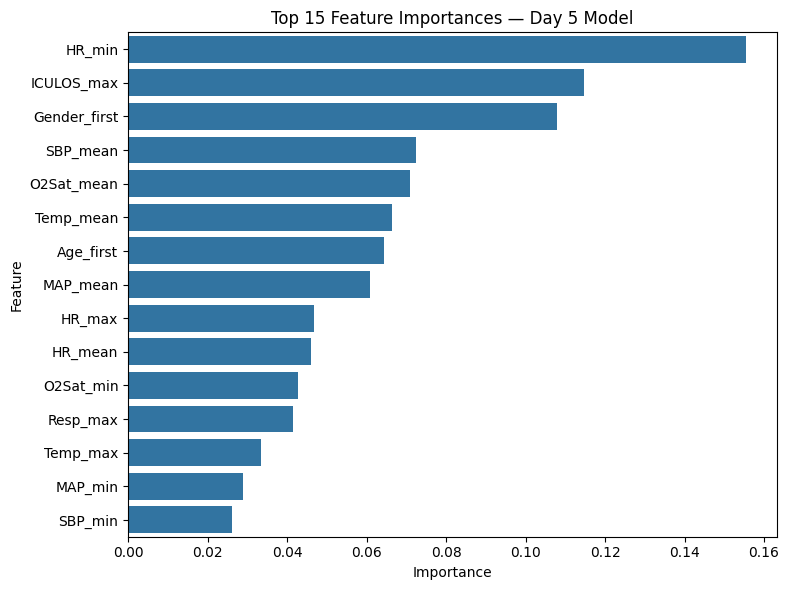

In [29]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances — Day 5 Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../figures/day5/day5_feature_importance.png", dpi=300)
plt.show()

## Exporting Day 5 Results

Model metrics, threshold optimization results, and feature importance values are exported for reporting and documentation.

In [30]:
day5_results = pd.DataFrame([rf_metrics, optimized_metrics])

day5_results.to_csv("../results/day5_model_results.csv", index=False)
threshold_df.to_csv("../results/day5_threshold_optimization.csv", index=False)
feature_importance.to_csv("../results/day5_feature_importance.csv", index=False)

print("Day 5 results exported successfully.")

Day 5 results exported successfully.


# Day 5 Conclusion

Day 5 focused on improving septic patient detection using SMOTE oversampling and threshold optimization.

The main objective was to move beyond accuracy and focus on recall, which is more clinically important for early sepsis warning systems.

This step improved the medical relevance of the project by prioritizing the detection of high-risk septic patients.